In [1]:
import torch
import torch.nn as nn 
from torch.func import jacrev
from torch.func import vmap

import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 8)

device = 'cuda'

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
'''
 concept: 
    1. we have a unicycle with CONSTANT input and FIXED time interval for the simulation
    2. define dataset as [t, g=(x, y, theta)]
    3. train std pinn 

    state: [x, y, theta]
    input: [v, w] --> const
 '''
' '

' '

In [5]:
# Piecewise constant control using expanded commands
# used for save and generate the constant command over the interval 

class ExpandedControl:
    def __init__(self, expanded_time, expanded_commands):
        self.expanded_time = expanded_time
        self.expanded_commands = expanded_commands

    def __call__(self, t):
        idx = np.searchsorted(self.expanded_time, t, side='right') - 1
        idx = np.clip(idx, 0, len(self.expanded_commands) - 1)
        return self.expanded_commands[idx]

In [4]:
#@ pinn Dataset  (NOT pinn-C) --> constant control over entire trajectory
# # first test: unicycle kinematics with constant input 
def control_input():

    return np.array([1, 0.1])

def kin_unicycle(t, x):

    u = control_input()
    dx = np.zeros(3)
    dx[0] = np.cos(x[2])*u[0]
    dx[1] = np.sin(x[2])*u[0]
    dx[2] = u[1]
    return dx


time_range = [0.0, 20.0]
time_eval = np.linspace(time_range[0], time_range[1], 1000)

init_condition_X = np.array([0, 0, 0])

# not used for now
init_condition_U = np.array([1, 0.1]) 

unikin_integration = solve_ivp(
    kin_unicycle,
    time_range,
    init_condition_X, 
    t_eval=time_eval)

In [19]:
#@ Pinn-C dataset (with control input)

time_range = [0.0, 20.0]
time_points = np.linspace(time_range[0], time_range[1], 1000)

commands = np.zeros((len(time_points), 2))
# smooth input 
commands[:, 0] = 0.2 + 0.5* np.random.rand(time_points.shape[0])
commands[:, 1] = 0.1 * np.sin(0.5 * time_points) - np.cos(0.1 * time_points)

# downsample the commands: constant for each 5 timestep
# 1 timestep = 20.0 sec / 1000 time_step = 0.02 sec


delta_t = 10
T_max = delta_t * 0.02 
for i in range(0, len(time_points), delta_t):
    commands[i:i+delta_t, 0] = commands[i, 0]
    commands[i:i+delta_t, 1] = commands[i, 1]

control = ExpandedControl(time_points, expanded_commands=commands)


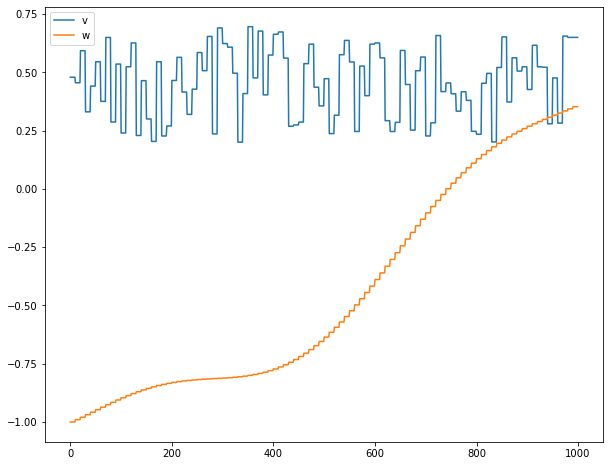

In [20]:
plt.plot(control(time_points)[:, 0], label='v')
plt.plot(control(time_points)[:, 1], label='w')
plt.legend()

In [21]:
# Kinematic model of the unicycle
def kin_unicycle(t, x, control_input):
    u = control(t)  # Get the control input at time `t`
    dx = np.zeros(3)
    dx[0] = np.cos(x[2]) * u[0]
    dx[1] = np.sin(x[2]) * u[0]
    dx[2] = u[1]
    return dx

# Integration parameters
init_condition_X = np.array([0, 0, 0])

# Solve the unicycle model
unikin_integration = solve_ivp(
    lambda t, x: kin_unicycle(t, x, control),
    time_range,
    init_condition_X,
    t_eval=time_points,
)


# Access results
t_values = unikin_integration.t
trajectory = unikin_integration.y



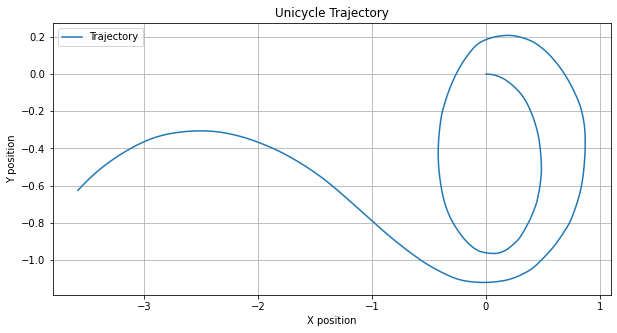

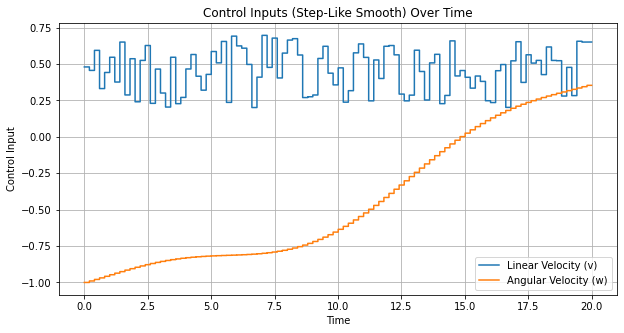

In [23]:
#@ Plot results
# Plot trajectory
plt.figure(figsize=(10, 5))
plt.plot(trajectory[0], trajectory[1], label="Trajectory")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Unicycle Trajectory")
plt.legend()
plt.grid()

# Plot control inputs over time
plt.figure(figsize=(10, 5))
plt.step(t_values, commands[:, 0], label="Linear Velocity (v)", where='post')
plt.step(t_values, commands[:, 1], label="Angular Velocity (w)", where='post')
plt.xlabel("Time")
plt.ylabel("Control Input")
plt.title("Control Inputs (Step-Like Smooth) Over Time")
plt.legend()
plt.grid()

plt.show()


In [26]:
#@ NON-SAMPLED DATA
# this cell generate a full trajectory [except the last N point saved for eval]

X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1]-(200), delta_t): # step di 5

    # input
    T = np.linspace(0, T_max, delta_t).reshape(-1, 1)
    x_0 = trajectory[:, i, np.newaxis]
    x_0 = x_0.repeat(delta_t, axis=1).T  # 3x5 --> (x, y, 0) for 5 time step
    const_commands = commands[i:i+delta_t, :]

    X = np.hstack([x_0, const_commands, T])
    X_dataset.append(X)

    # output
    Y = trajectory[:, i:i+delta_t].T
    Y_dataset.append(Y)

X_train = np.concatenate(X_dataset)
Y_train = np.concatenate(Y_dataset)


In [27]:
# eval dataset
X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1], delta_t): # step di 5

    T = np.array([T_max]).reshape(1, -1)
    x_0 = trajectory[:, i, np.newaxis]
    const_commands = commands[i, :].reshape(1, -1).T
    X = np.vstack([
        x_0,
        const_commands,
        T])

    X_dataset.append(X)
    Y_dataset.append(trajectory[:, i].T)

X_eval = np.hstack(X_dataset).T
Y_eval = np.stack(Y_dataset)

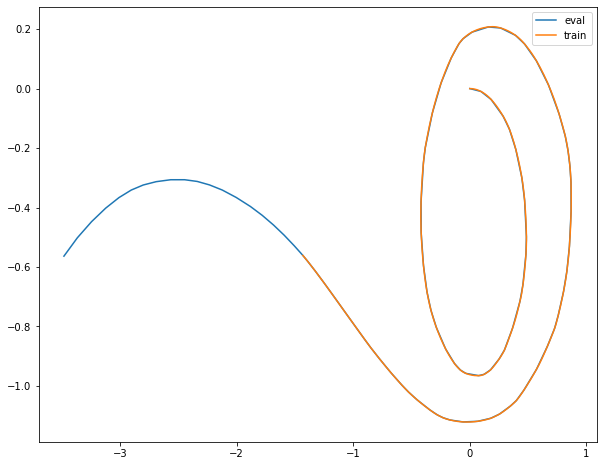

In [28]:
plt.plot(Y_eval[:, 0], Y_eval[:, 1], label='eval')
plt.plot(Y_train[:, 0], Y_train[:, 1], label='train')
plt.legend()

In [29]:
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_eval = torch.tensor(X_eval, dtype=torch.float32, device=device)
Y_eval = torch.tensor(Y_eval, dtype=torch.float32, device=device)

In [30]:

t_max, t_min = torch.tensor([T_max], device=device), torch.tensor([0.0], device=device)
x_max, x_min = Y_eval.max(0)[0][0].to(device), Y_eval.min(0)[0][0].to(device) 
y_max, y_min = Y_eval.max(0)[0][1].to(device), Y_eval.min(0)[0][1].to(device)
theta_max, theta_min = Y_eval.max(0)[0][2].to(device), Y_eval.min(0)[0][2].to(device)

In [31]:
u_max, u_min = commands.max(0)[0], commands.min(0)[0]
w_max, w_min = commands.max(0)[1], commands.min(0)[1]

In [32]:
pinn_c = nn.Sequential(
    nn.Linear(6, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 3)
).to(device)

pinn_c_opti = torch.optim.Adam(pinn_c.parameters(), lr=1e-4)
loss_mse = nn.MSELoss()
epoch_counter = 0

In [41]:
for i in range(10_000):

    epoch_counter += 1
    pinn_c_opti.zero_grad()

    pred = pinn_c(X_train)

    # loss by imit datapoint
    loss_imit = loss_mse(pred, Y_train)

    # loss by pinn
    N_sample = 2_000
    # random time in range(0, 0.01)
    sampled_t = torch.rand(N_sample, 1).to(device) * (t_max - t_min) + t_min
    
    # random sample
    sampled_x = torch.rand(N_sample, 1).to(device) * (x_max - x_min) + x_min
    sampled_y = torch.rand(N_sample, 1).to(device) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(N_sample, 1).to(device) * (theta_max - theta_min) + theta_min

    # random input
    sampled_u = torch.randn(N_sample, 1).to(device) * (u_max - u_min) + u_min
    sampled_w = torch.randn(N_sample, 1).to(device) * (w_max - w_min) + w_min

    # concat the random componet
    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, 
        sampled_u, sampled_w, 
        sampled_t
    ], -1).to(device)
    sample.requires_grad = True

    # physical system prediction

    pred_output = pinn_c(sample)
    # calc jacobian respect the output of the net
    d_output = vmap(jacrev(pinn_c))(sample).squeeze()
    # extract derivative respect time --> dx_dt, dy_dt, dtheta_dt
    d_output = d_output[:, :, -1]


    # compute the ode of the kin model
    pred_dx = torch.cos(pred_output[:, 2]) * control_input()[0]
    pred_dy = torch.sin(pred_output[:, 2]) * control_input()[0]
    pred_dtheta = (control_input()[1] * torch.ones(pred_dy.shape[0])).to(device)

    physics_val = torch.vstack([pred_dx, pred_dy, pred_dtheta]).T

    # compute the cost 
    F_cost = torch.mean(torch.mean((physics_val - d_output)**2, axis=1))


    # boundary condition: No input AKA no velocity

    # no velocity ---> no motion:
    # opt 1: apply this at gradient level:
    
    # dx = 0 * cos(*) = 0
    # dy = 0 * sin(*) = 0
    # dtheta = 0

    # opt 2 : apply this at prediciton level:
    # given x --> f(x) = x (no motion)


    loss = loss_imit + F_cost
    

    loss.backward()
    pinn_c_opti.step()

    if i % 100 == 0:
        print(f'iter: {epoch_counter} Loss: {loss.item()}, loss_imit: {loss_imit.item()}, F_cost: {F_cost.item()}')
        

iter: 40001 Loss: 0.0011327957035973668, loss_imit: 0.0010272628860548139, F_cost: 0.00010553281754255295
iter: 40101 Loss: 0.0011339548509567976, loss_imit: 0.0010270547354593873, F_cost: 0.0001069001664291136
iter: 40201 Loss: 0.0011430111480876803, loss_imit: 0.0010241123382002115, F_cost: 0.00011889878805959597
iter: 40301 Loss: 0.001127144554629922, loss_imit: 0.0010286440374329686, F_cost: 9.850046626525e-05
iter: 40401 Loss: 0.0011356936302036047, loss_imit: 0.001028232742100954, F_cost: 0.0001074609172064811
iter: 40501 Loss: 0.0011316458694636822, loss_imit: 0.00102805916685611, F_cost: 0.00010358668077969924
iter: 40601 Loss: 0.0011146871838718653, loss_imit: 0.0010263416916131973, F_cost: 8.834549953462556e-05
iter: 40701 Loss: 0.001141960732638836, loss_imit: 0.0010281812865287066, F_cost: 0.00011377946066204458
iter: 40801 Loss: 0.001141310203820467, loss_imit: 0.0010273450752720237, F_cost: 0.00011396507761674002
iter: 40901 Loss: 0.001134038669988513, loss_imit: 0.001025

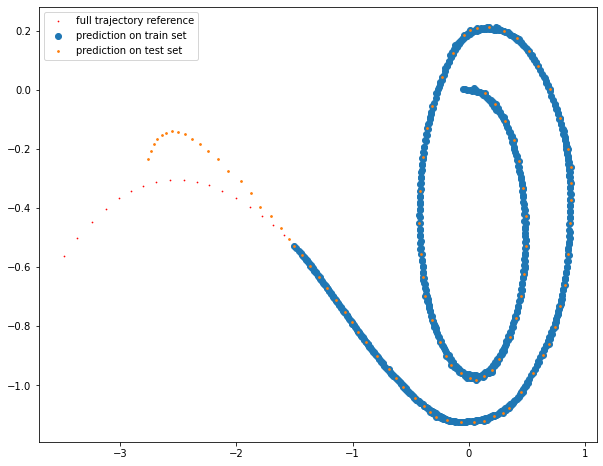

In [42]:
pred_full_traj = pinn_c(X_eval).detach().cpu().numpy().T
pred = pinn_c(X_train).detach().cpu().numpy().T
#plt.scatter(Y_train[0], Y_train[1], label='data points train')
plt.scatter(Y_eval.detach().cpu().numpy()[:, 0], Y_eval.detach().cpu().numpy()[:, 1], c='r', s=0.5, label='full trajectory reference')
plt.scatter(pred[0], pred[1], label='prediction on train set')
plt.scatter(pred_full_traj[0], pred_full_traj[1], label='prediction on test set', s=3)

plt.legend()


# this part contains dev stuff --> first test on how move from pinn to pinn-c
just keep it in case we'll need it. Not really important for now to read and clean. The code ends here

In [171]:
#DATASET
#dataset 
dataset_X_train = []
dataset_Y_train = []

dataset_X_full = []
dataset_Y_full = []

init_condition_X = np.array([
    [0, 1, 0], 
    [1, 0, -np.pi/2],
])

n_traj = 2
for traj_id in range(n_traj):

    time_range = [0.0, 20.0]
    time_eval = np.linspace(time_range[0], time_range[1], 1000)

    # init condition change to random 
    # init_condition_X = np.array([0, 0, 0])
    #init_condition_X = np.random.rand(3)

    # not used for now
    init_condition_U = np.array([1, 0.1]) 

    unikin_integration = solve_ivp(
        kin_unicycle,
        time_range,
        init_condition_X[traj_id], 
        t_eval=time_eval)
        

    solution = unikin_integration.y
    time_input = unikin_integration.t

    idx = np.random.randint(0, len(solution[0])-100, int(len(solution[0])*0.06))

    X_train = torch.hstack(
        [(torch.ones(len(idx), 3) * init_condition_X[traj_id]), torch.FloatTensor(time_input[idx]).view(-1, 1)]
        ).to(device)
    X_train.requires_grad = True

    Y_train = torch.FloatTensor(solution[:, idx], device=device)

    X_full = torch.hstack(
        [(torch.ones(len(time_input), 3) * init_condition_X[traj_id]), torch.FloatTensor(time_input).view(-1, 1),]
    ).to(device)
    Y_full = torch.FloatTensor(solution, device=device)


    dataset_X_train.append(X_train)
    dataset_Y_train.append(Y_train)
    dataset_X_full.append(X_full)
    dataset_Y_full.append(Y_full)

X_train = torch.vstack(dataset_X_train).to(torch.float32)
Y_train = torch.hstack(dataset_Y_train).to(torch.float32)

X_full = torch.vstack(dataset_X_full).to(torch.float32)
Y_full = torch.hstack(dataset_Y_full).to(torch.float32)

TypeError: kin_unicycle() missing 1 required positional argument: 'control_input'

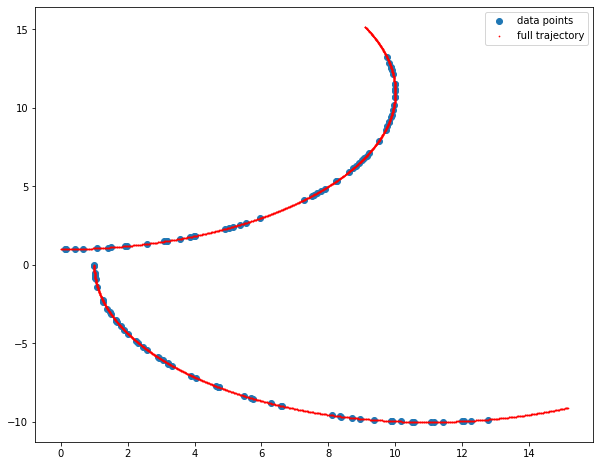

In [106]:
plt.scatter(Y_train[0], Y_train[1], label='data points')   
plt.scatter(Y_full[0], Y_full[1], c='r', s=0.5, label='full trajectory')
plt.legend()
plt.show()

In [107]:
pinn = torch.nn.Sequential(
    torch.nn.Linear(4, 32),
    torch.nn.Tanh(),
    torch.nn.Linear(32, 50),
    torch.nn.Tanh(),
    torch.nn.Linear(50, 3)
)
basic_opti = torch.optim.Adam(pinn.parameters(), lr=1e-4)
loss_mse = torch.nn.MSELoss()
epoch_counter = 0

min_t = 0
max_t = 20.


In [76]:
sampled_t = torch.rand(300, 1) * (max_t - min_t) + min_t
sampled_t = sampled_t.to(device)    
sampled_t.requires_grad = True  


In [115]:
d_output.shap

torch.Size([300, 3])

In [90]:
x_min, y_min, theta_min = X_full.min(0)[0][1:]
x_max, y_max, theta_max = X_full.max(0)[0][1:]

In [131]:
for i in range(2_000):

    epoch_counter += 1
    basic_opti.zero_grad()

    pred = pinn(X_train).T

    # loss by imit datapoint
    loss_imit = loss_mse(pred, Y_train)

    # loss by pinn
    sampled_t = torch.rand(300, 1) * (max_t - min_t) + min_t
    sampled_x = torch.rand(300, 1) * (x_max - x_min) + x_min
    sampled_y = torch.rand(300, 1) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(300, 1) * (theta_max - theta_min) + theta_min

    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, sampled_t
    ], -1).to(device)
    sample.requires_grad = True


    # dx_dt, dy_dt, dtheta_dt
    pred_output = pinn(sample)
    # calc jacobian 
    d_output = vmap(jacrev(pinn))(sample).squeeze()
    # extract derivative respect time
    d_output = d_output[:, :, -1]


    pred_dx = torch.cos(pred_output[:, 2]) * control_input()[0]
    pred_dy = torch.sin(pred_output[:, 2]) * control_input()[0]
    pred_dtheta = control_input()[1] * torch.ones(pred_dy.shape[0])

    physics_val = torch.vstack([pred_dx, pred_dy, pred_dtheta]).T

    F_cost = 10*torch.mean(torch.mean((physics_val - d_output)**2, axis=1))


    loss = loss_imit + F_cost
    

    loss.backward()
    basic_opti.step()

    if i % 100 == 0:
        print(f'iter: {epoch_counter} Loss: {loss.item()}, loss_imit: {loss_imit.item()}, F_cost: {F_cost.item()}')
        

iter: 17004 Loss: 0.00040817534318193793, loss_imit: 3.385647141840309e-05, F_cost: 0.00037431888631545007
iter: 17104 Loss: 0.0002971410285681486, loss_imit: 3.06738365907222e-05, F_cost: 0.0002664671919774264
iter: 17204 Loss: 0.0002956700627692044, loss_imit: 3.1058887543622404e-05, F_cost: 0.0002646111825015396
iter: 17304 Loss: 0.00028872740222141147, loss_imit: 2.802848393912427e-05, F_cost: 0.0002606989291962236
iter: 17404 Loss: 0.0002701735938899219, loss_imit: 2.7411122573539615e-05, F_cost: 0.00024276248586829752
iter: 17504 Loss: 0.0004276130348443985, loss_imit: 2.6448475182405673e-05, F_cost: 0.0004011645505670458
iter: 17604 Loss: 0.00032994194771163166, loss_imit: 2.3531891201855615e-05, F_cost: 0.0003064100455958396
iter: 17704 Loss: 0.00024442889844067395, loss_imit: 2.4049020794336684e-05, F_cost: 0.00022037986491341144
iter: 17804 Loss: 0.0002854383201338351, loss_imit: 2.3526159566245042e-05, F_cost: 0.000261912151472643
iter: 17904 Loss: 0.0002609544026199728, los

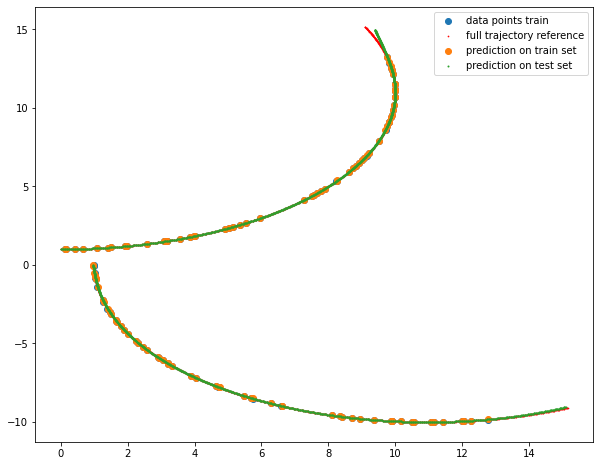

In [132]:
pred_full_traj = pinn(X_full).T.detach().numpy()

plt.scatter(Y_train[0], Y_train[1], label='data points train')
plt.scatter(Y_full[0], Y_full[1], c='r', s=0.5, label='full trajectory reference')
plt.scatter(pred[0].detach().numpy(), pred[1].detach().numpy(), label='prediction on train set')
plt.scatter(pred_full_traj[0], pred_full_traj[1], label='prediction on test set', s=1)

plt.legend()


## note
    1 - non ci sta il problema della concatenazione degli stati, input solo t
    2 - qui abbiamo solo input constanti. Eppure la C-pinn funziona in input constanti durante il sample.
        # quando risolviamo il sistema con solve_ivp, il time eval e' quello da attenzionare. Il t sara' costante in quel range 

@TODO
    
    # then ok think about the varing control input

    
    
